In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("titanic.csv",usecols=["Survived","Age","Fare"])


In [4]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
df["Age_Mean_imputed"]=df["Age"].fillna(value=df["Age"].mean())
df["Age_Median_imputed"]=df["Age"].fillna(value=df["Age"].median())

In [7]:
df.sample(10)

,Survived,Age,Fare,Age_Mean_imputed,Age_Median_imputed
562,0,28.0,13.5000,28.000000,28.0
669,1,NaN,52.0000,29.699118,28.0
635,1,28.0,13.0000,28.000000,28.0
448,1,5.0,19.2583,5.000000,5.0
661,0,40.0,7.2250,40.000000,40.0
368,1,NaN,7.7500,29.699118,28.0
394,1,24.0,16.7000,24.000000,24.0
815,0,NaN,0.0000,29.699118,28.0
546,1,19.0,26.0000,19.000000,19.0
662,0,47.0,25.5875,47.000000,47.0


In [8]:
# checking whether imputation applied correct or not ---> calculating variance before and after imputation . if no large diff then okay
print("age variance before imputation",df["Age"].var())
print("age variance after imputation(mean)",df["Age_Mean_imputed"].var())
print("age variance after imputation(median)",df["Age_Median_imputed"].var())


'''
While applying mean or median imputation,
 we should compare the feature's distribution before and after imputation. 
 Since replacing missing values with a constant reduces spread, variance usually decreases slightly. 
 A large change in variance or distribution indicates that the imputation may be introducing bias and another technique should be considered.
'''

age variance before imputation 211.01912474630802
age variance after imputation(mean) 169.0523999372108
age variance after imputation(median) 169.51249827942345


"\nWhile applying mean or median imputation,\n we should compare the feature's distribution before and after imputation. \n Since replacing missing values with a constant reduces spread, variance usually decreases slightly. \n A large change in variance or distribution indicates that the imputation may be introducing bias and another technique should be considered.\n"

<Axes: ylabel='Density'>

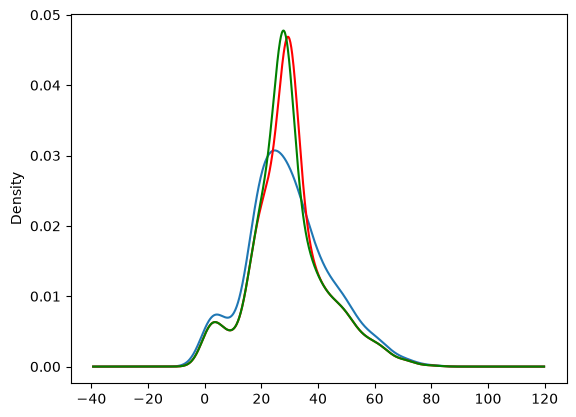

In [9]:
# distribution
# distribution
import matplotlib.pyplot as plt
fig=plt.figure()
ax=fig.add_subplot()
df["Age"].plot(kind="kde",ax=ax)
df["Age_Mean_imputed"].plot(kind="kde",ax=ax,color="red")
df["Age_Median_imputed"].plot(kind="kde",ax=ax,color="green")

In [10]:
df.describe()

,Survived,Age,Fare,Age_Mean_imputed,Age_Median_imputed
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,29.699118,32.204208,29.699118,29.361582
std,0.486592,14.526497,49.693429,13.002015,13.019697
min,0.000000,0.420000,0.000000,0.420000,0.420000
25%,0.000000,20.125000,7.910400,22.000000,22.000000
50%,0.000000,28.000000,14.454200,29.699118,28.000000
75%,1.000000,38.000000,31.000000,35.000000,35.000000
max,1.000000,80.000000,512.329200,80.000000,80.000000


In [ ]:
df.corr() # there should not be big deviation after and before imputation in correlation

,Survived,Age,Fare,Age_Mean_imputed,Age_Median_imputed
Survived,1.000000,-0.077221,0.257307,-0.069809,-0.064910
Age,-0.077221,1.000000,0.096067,1.000000,1.000000
Fare,0.257307,0.096067,1.000000,0.091566,0.096688
Age_Mean_imputed,-0.069809,1.000000,0.091566,1.000000,0.998642
Age_Median_imputed,-0.064910,1.000000,0.096688,0.998642,1.000000


HANDLING MISSING CATEGORICAL DATA